# load file

In [104]:
from scipy.io import loadmat
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [105]:
data = loadmat("Shoe25OpenSim_python.mat")
print(data.keys())

angles = data['ANGLES_TABLE'][0,0]
print(angles.dtype.names)

angles_curve_1 = angles["x25_Curve_1_mat"]
print(type(angles_curve_1))

print(angles_curve_1.shape)


dict_keys(['__header__', '__version__', '__globals__', 'ANGLES_TABLE', 'ANGLES_TABLE_FILT', 'ANGULAR_VELOCITY_TABLE_FILT', 'CONTACT_ANALOG', 'CONTACT_KINEMATIC', 'GRF_TABLE', 'MARKERS', 'OPTIONS', 'S', 'data', 'f', 'i', 'name', 'v', 'value', 'varname', 'vars', '__function_workspace__'])
('x25_Curve_1_mat', 'x25_Curve_4_mat', 'x25_Straight_T1_mat')
<class 'numpy.ndarray'>
(67, 40)


In [106]:
data_labels = loadmat("angles_with_labels.mat")

raw_labels = data_labels["angle_labels"]

labels = [str(x[0]) for x in raw_labels[0]]

print(labels)

['time', 'pelvis_tilt', 'pelvis_list', 'pelvis_rotation', 'pelvis_tx', 'pelvis_ty', 'pelvis_tz', 'hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'knee_angle_r_beta', 'ankle_angle_r', 'subtalar_angle_r', 'mtp_angle_r', 'hip_flexion_l', 'hip_adduction_l', 'hip_rotation_l', 'knee_angle_l', 'knee_angle_l_beta', 'ankle_angle_l', 'subtalar_angle_l', 'mtp_angle_l', 'lumbar_extension', 'lumbar_bending', 'lumbar_rotation', 'arm_flex_r', 'arm_add_r', 'arm_rot_r', 'elbow_flex_r', 'pro_sup_r', 'wrist_flex_r', 'wrist_dev_r', 'arm_flex_l', 'arm_add_l', 'arm_rot_l', 'elbow_flex_l', 'pro_sup_l', 'wrist_flex_l', 'wrist_dev_l']


In [107]:
angle_dict = {}

for n in range(len(labels)):
    angle_dict[labels[n]] = angles_curve_1[:,n]

#### TO DO hieronder: 
###### - make a module where there are the different types of plots (angles, force data,...) and then make sheets where the results of every shoe can be assesed
###### - curve_4 => noise na sec ... (denk 6) -> hoe oplossen?
###### - insert a dialog box to make it more user friendly

In [108]:
def get_angle_data(joint, trial="Curve_1", specification="Rotation", header="ANGLES_TABLE"):
    type_data = data[header][0,0]
    trial_data = type_data[f"x25_{trial}_mat"]

    angle_dict_local = {labels[n]: trial_data[:, n] for n in range(len(labels))}
    x = trial_data[:, 0]

    if joint in ["ankle", "knee"]:
        y_l = [angle_dict_local[k] for k in angle_dict_local.keys() if joint in k and k.endswith("_l")][0]
        y_r = [angle_dict_local[k] for k in angle_dict_local.keys() if joint in k and k.endswith("_r")][0]
        return x, y_l, y_r

    elif joint == "hip":
        y_l = [angle_dict_local[k] for k in angle_dict_local.keys() if specification.lower() in k and k.endswith("_l")][0]
        y_r = [angle_dict_local[k] for k in angle_dict_local.keys() if specification.lower() in k and k.endswith("_r")][0]
        return x, y_l, y_r

    else:
        y = [angle_dict_local[k] for k in angle_dict_local.keys() if joint in k and specification.lower() in k][0]
        return x, y

In [109]:
def plot_angle(joint, trial="Curve_1", specification="Rotation"):
    result = get_angle_data(joint, trial, specification)

    if len(result) == 3:
        _, y_l, y_r = result
        if joint != "hip":
            label = "Angle"
        else: 
            label = f"{specification}"
        plt.plot(_, y_l, color="red", label="Left")
        plt.plot(_, y_r, color="blue", label="Right")
        plt.xlabel("Time (s)")
        plt.ylabel(label)
        plt.title(f"{joint.capitalize()} angle")
        plt.legend()
        return plt.show()
    
    else:
        _, y = result
        label = f"{specification}"
        plt.plot(_, y, color="green", label=f"{specification}")
        plt.xlabel("Time (s)")
        plt.ylabel(label)
        plt.title(f"{joint.capitalize()} angle")
        plt.legend()
        return plt.show()

In [110]:
def stat_angle(joint, stat="mean", trial="Curve_1", specification="Rotation"):
    result = get_angle_data(joint, trial, specification)

    func = getattr(np, stat)
    
    if len(result) == 3:
        _, y_l, y_r = result
        return func(y_l), func(y_r)
    else:
        _, y = result
        return func(y)


In [111]:
angle_l, angle_r = stat_angle("ankle", stat="max", trial="Straight_T1")

print(f"max angle left = {angle_l}°")

max angle left = 9.91246021°


#### Ankle Plots

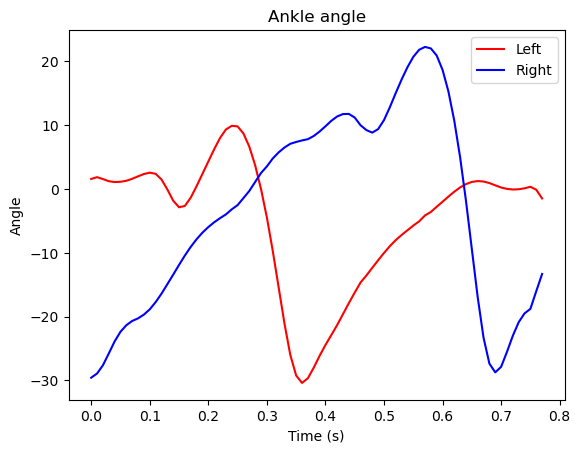

In [112]:
plot_angle("ankle", trial="Straight_T1")

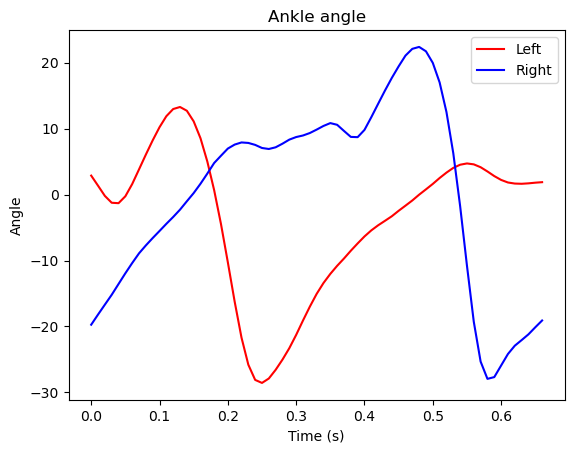

In [113]:
plot_angle("ankle", trial="Curve_1")

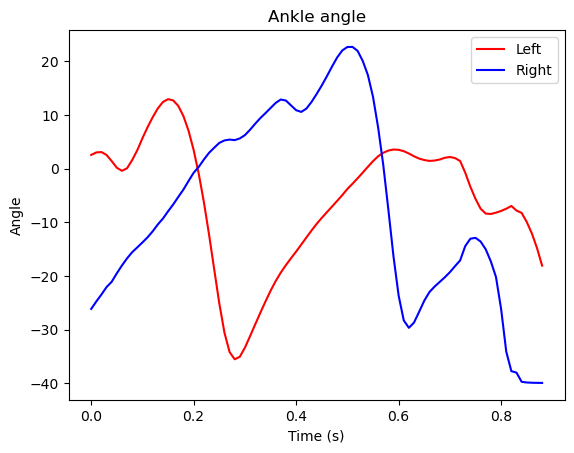

In [114]:
plot_angle("ankle", trial="Curve_4")

#### Hip plots

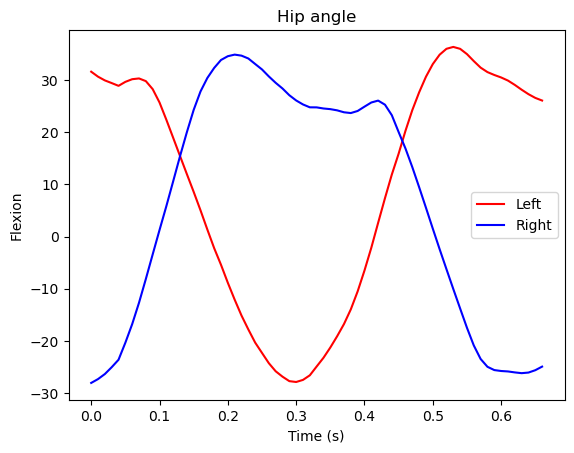

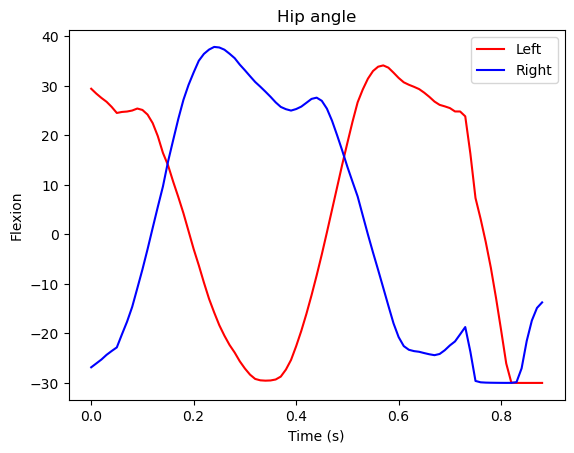

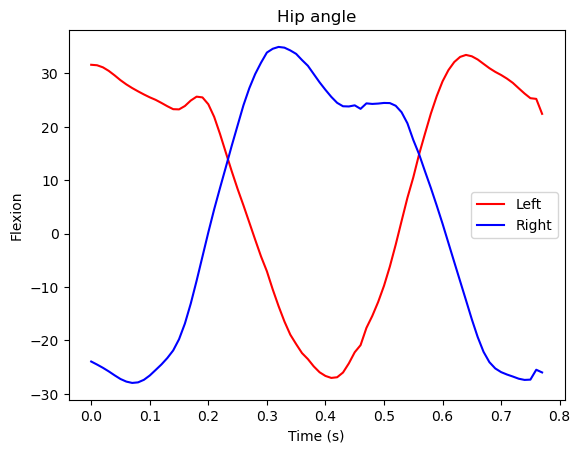

max angle left hip on a curve = 35.250677825°
max angle right hip on a curve = 36.379178085°
max angle left hip on the straight = 33.47287167°
max angle right hip on the straight = 34.97117162°


In [115]:
plot_angle("hip", trial="Curve_1", specification= "Flexion")
plot_angle("hip", trial="Curve_4", specification= "Flexion")
plot_angle("hip", trial="Straight_T1", specification= "Flexion")

angle_c1l, angle_c1r = stat_angle("hip", stat="max", trial= "Curve_1", specification= "Flexion")
angle_c4l, angle_c4r = stat_angle("hip", stat="max", trial= "Curve_4",specification= "Flexion")
angle_s1l, angle_s1r = stat_angle("hip", stat="max", trial= "Straight_T1",specification= "Flexion")

print(f"max angle left hip on a curve = {np.mean([angle_c1l, angle_c4l])}°")
print(f"max angle right hip on a curve = {np.mean([angle_c1r, angle_c4r])}°")
print(f"max angle left hip on the straight = {angle_s1l}°")
print(f"max angle right hip on the straight = {angle_s1r}°")



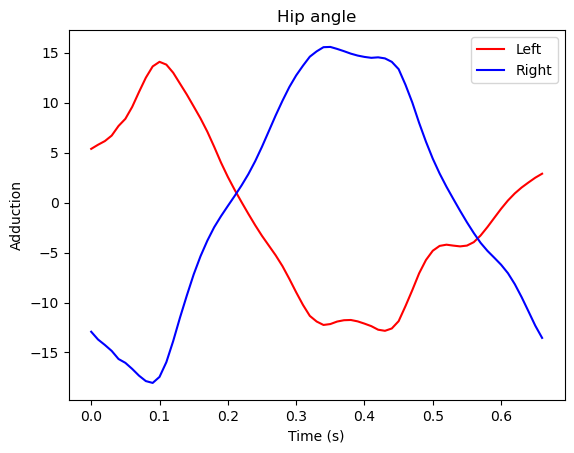

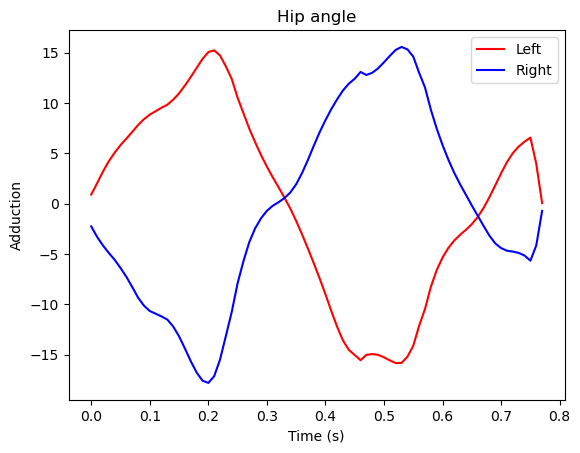

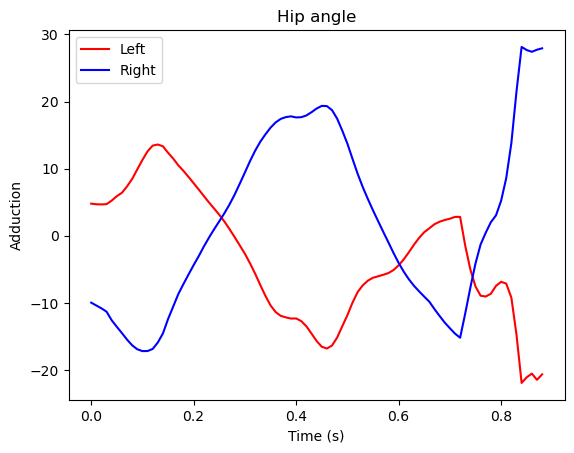

In [116]:
plot_angle("hip", trial="Curve_1", specification= "Adduction")
plot_angle("hip", trial="Straight_T1", specification= "Adduction")
plot_angle("hip", trial="Curve_4", specification= "Adduction")

In [117]:
plot_angle

<function __main__.plot_angle(joint, trial='Curve_1', specification='Rotation')>

#### Pelvis plots


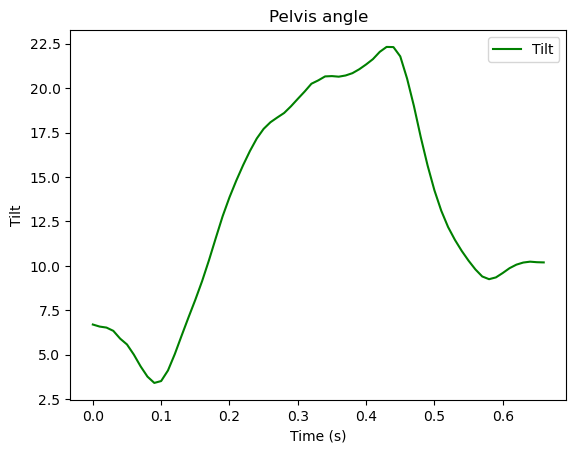

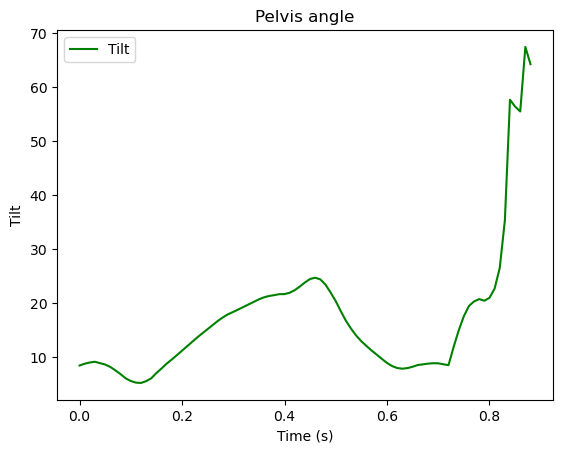

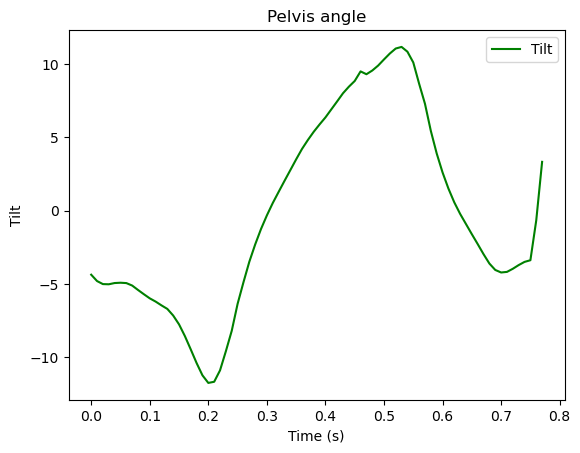

In [118]:
plot_angle("pelvis", trial="Curve_1", specification= "Tilt")
plot_angle("pelvis", trial="Curve_4", specification= "Tilt")
plot_angle("pelvis", trial="Straight_T1", specification= "Tilt")

#### Tilt:
###### curve: niet onder 0 -> altijd naar links getilt en nooit rechts: zelfs heel grote tilt bij rechterstap

###### straight: evenveel neg als pos -> normale waarden voor een lopen in een rechte lijn